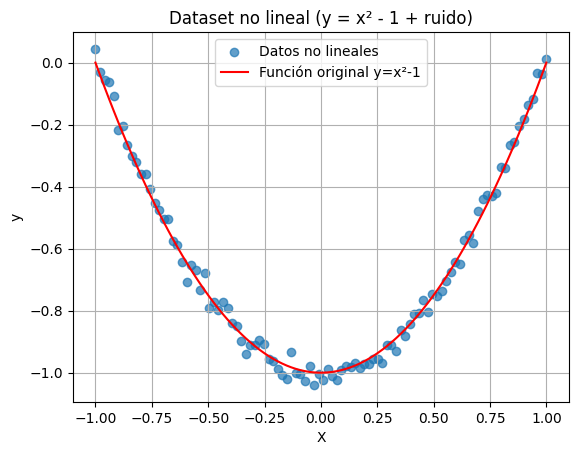

In [60]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import classification_report

# Dataset no lineal: y = x² - 1 + ruido
np.random.seed(0)
X = np.linspace(-1, 1, 100)
y = X**2 - 1 + np.random.normal(0, .025, size=X.shape)
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .5, random_state = 123)

# Visualización
plt.scatter(X, y, label='Datos no lineales', alpha=0.7)
plt.plot(X, X**2 - 1, color='red', label='Función original y=x²-1')
plt.xlabel("X")
plt.ylabel("y")
plt.title("Dataset no lineal (y = x² - 1 + ruido)")
plt.legend()
plt.grid()
plt.show()


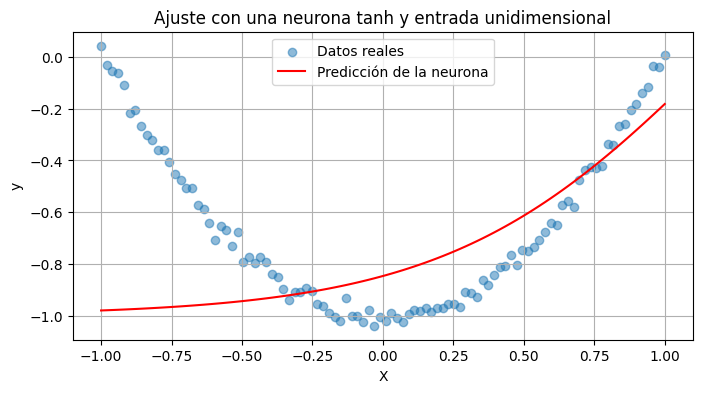

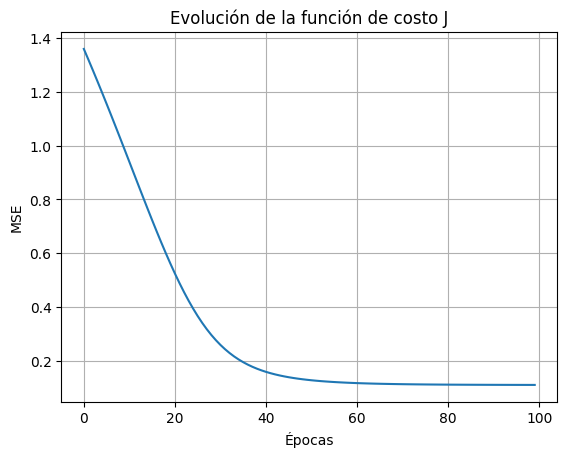

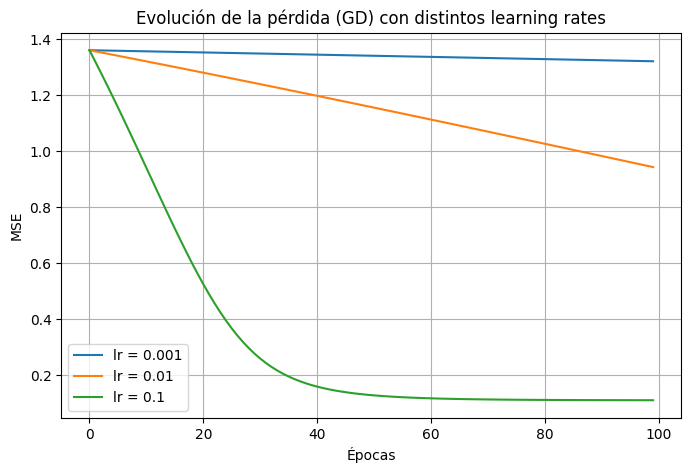

In [61]:
# Activación tanh y su derivada
def tanh(x):
    return np.tanh(x)

def tanh_deriv(x):
    return 1 - np.tanh(x) ** 2

# Neurona con tanh 
def single_neuron_tanh(X, y, lr=0.1, epochs=100):
    """
    Trains a single neuron model using the hyperbolic tangent (tanh) activation function.
    Parameters:
    -----------
    X : numpy.ndarray
        Input feature(s), expected to be a 1D array. It will be reshaped into a column vector.
    y : numpy.ndarray
        Target values, expected to be a 1D array. It will be reshaped into a column vector.
    lr : float, optional
        Learning rate for gradient descent. Default is 0.1.
    epochs : int, optional
        Number of iterations for training. Default is 100.
    Returns:
    --------
    w : float
        Trained weight for the input feature.
    b : float
        Trained bias term.
    loss_history : list
        List of loss values (mean squared error) for each epoch during training.
    Notes:
    ------
    - The function uses the tanh activation function and its derivative for backpropagation.
    - The weight and bias are initialized randomly using a fixed seed for reproducibility.
    - The loss is calculated as the mean squared error between the predicted and actual values.
    """
    X = X.reshape(-1, 1)  # aseguramos forma columna
    y = y.reshape(-1, 1)  # aseguramos columna
    
    # Inicialización
    np.random.seed(0)
    w = np.random.randn()  # peso para x
    b = np.random.randn()
    loss_history = []
    trace = []  # para almacenar la evolución del modelo

    for i in range(epochs):
        z = X * w + b
        y_hat = tanh(z)
        error = y_hat - y
        dz = error * tanh_deriv(z)
        
        dw = np.mean(dz * X)
        db = np.mean(dz)

        w -= lr * dw
        b -= lr * db

        J = np.mean((y_hat - y)**2)
        loss_history.append(J)
        trace.append((w, b, J))

    return w, b, loss_history, trace

# Entrenamos
w, b, losses, trace_gd = single_neuron_tanh(X, y)

# Predicción
y_pred = tanh(X * w + b)

# Gráfico de datos y predicción
plt.figure(figsize=(8,4))
plt.scatter(X, y, alpha=0.5, label="Datos reales")
plt.plot(X, y_pred, color='red', label="Predicción de la neurona")
plt.title("Ajuste con una neurona tanh y entrada unidimensional")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Curva de pérdida
plt.plot(losses)
plt.title("Evolución de la función de costo J")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# Probar con diferentes learning rates
lrs = [0.001, 0.01, 0.1]
losses_dict = {}

for lr in lrs:
    _, _, losses, _ = single_neuron_tanh(X, y, lr=lr)
    losses_dict[lr] = losses
    
plt.figure(figsize=(8, 5))

for lr, losses in losses_dict.items():
    plt.plot(losses, label=f"lr = {lr}")

plt.title("Evolución de la pérdida (GD) con distintos learning rates")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()


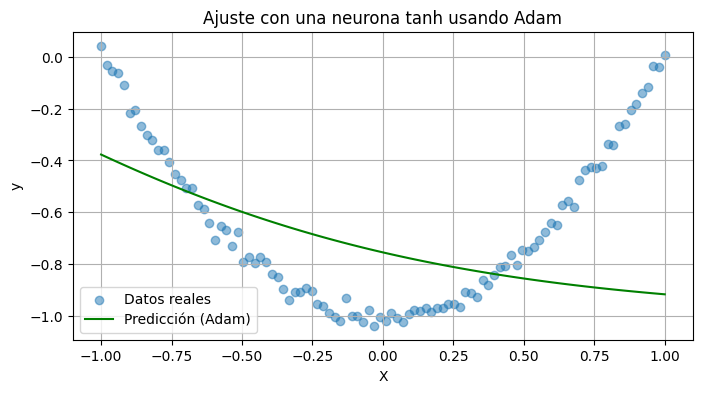

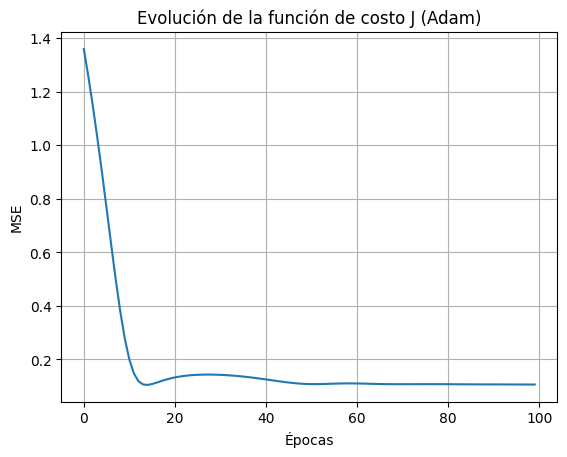

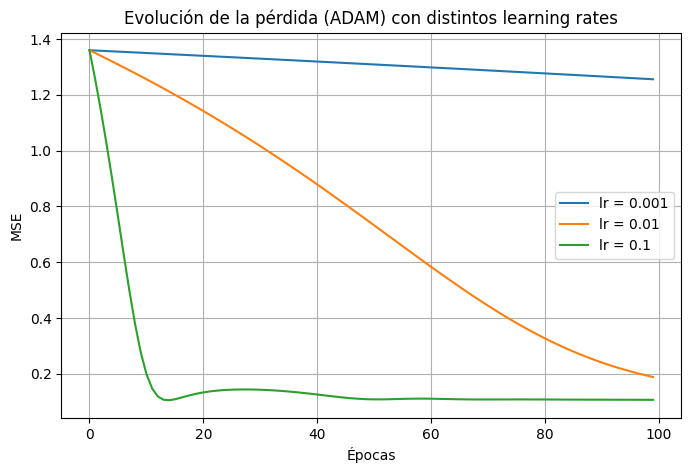

In [62]:
# Neurona con tanh usando Adam
def single_neuron_tanh_adam(X, y, lr=0.1, epochs=100, beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Entrena una única neurona usando activación tanh y el optimizador Adam.

    Parámetros:
    -----------
    X : numpy.ndarray
        Vector de entrada (1D), se convertirá a columna.
    y : numpy.ndarray
        Vector objetivo (1D), se convertirá a columna.
    lr : float
        Tasa de aprendizaje.
    epochs : int
        Número de épocas de entrenamiento.
    beta1, beta2 : float
        Coeficientes de decaimiento para los momentos.
    eps : float
        Término de estabilización numérica.

    Retorna:
    --------
    w : float
        Peso entrenado.
    b : float
        Sesgo entrenado.
    loss_history : list
        Historial de la función de pérdida.
    """
    X = X.reshape(-1, 1)
    y = y.reshape(-1, 1)

    # Inicialización
    np.random.seed(0)
    w = np.random.randn()
    b = np.random.randn()
    loss_history = []

    # Inicializar momentos para w y b
    mw, vw = 0.0, 0.0
    mb, vb = 0.0, 0.0
    trace = []  # Para guardar el rastro de los parámetros

    for t in range(1, epochs + 1):
        z = X * w + b
        y_hat = tanh(z)
        error = y_hat - y
        dz = error * tanh_deriv(z)

        dw = np.mean(dz * X)
        db = np.mean(dz)

        # Actualización de momentos (Adam)
        mw = beta1 * mw + (1 - beta1) * dw
        vw = beta2 * vw + (1 - beta2) * (dw ** 2)
        mw_corr = mw / (1 - beta1 ** t)
        vw_corr = vw / (1 - beta2 ** t)

        mb = beta1 * mb + (1 - beta1) * db
        vb = beta2 * vb + (1 - beta2) * (db ** 2)
        mb_corr = mb / (1 - beta1 ** t)
        vb_corr = vb / (1 - beta2 ** t)

        # Actualización de parámetros
        w -= lr * mw_corr / (np.sqrt(vw_corr) + eps)
        b -= lr * mb_corr / (np.sqrt(vb_corr) + eps)

        # Calcular pérdida y guardar
        J = np.mean((y_hat - y) ** 2)
        loss_history.append(J)
        trace.append((w, b, J))

    return w, b, loss_history, trace


# Entrenar usando Adam
w_adam, b_adam, losses_adam, trace_adam = single_neuron_tanh_adam(X, y)

# Predicción
y_pred_adam = tanh(X * w_adam + b_adam)

# Gráfico de ajuste
plt.figure(figsize=(8, 4))
plt.scatter(X, y, alpha=0.5, label="Datos reales")
plt.plot(X, y_pred_adam, color='green', label="Predicción (Adam)")
plt.title("Ajuste con una neurona tanh usando Adam")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

# Gráfico de pérdida
plt.plot(losses_adam)
plt.title("Evolución de la función de costo J (Adam)")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.grid(True)
plt.show()

# Probar con diferentes learning rates
lrs = [0.001, 0.01, 0.1]
losses_dict = {}

for lr in lrs:
    _, _, losses, _ = single_neuron_tanh_adam(X, y, lr=lr)
    losses_dict[lr] = losses
    
plt.figure(figsize=(8, 5))

for lr, losses in losses_dict.items():
    plt.plot(losses, label=f"lr = {lr}")

plt.title("Evolución de la pérdida (ADAM) con distintos learning rates")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)
plt.show()

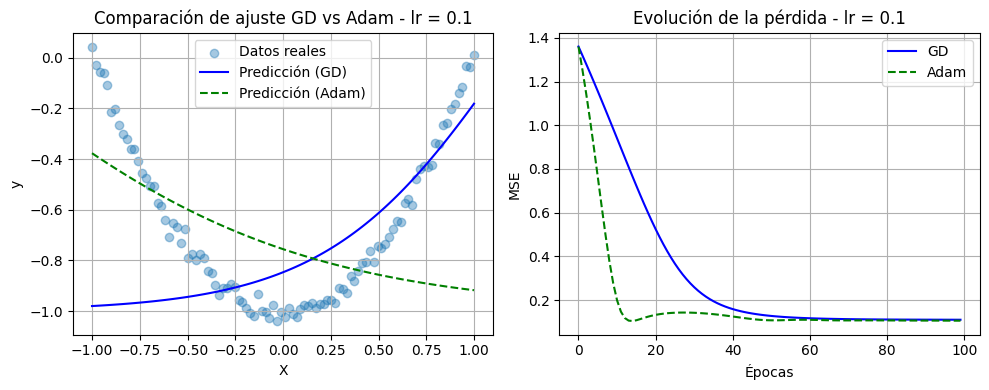

In [63]:
# Entrenar con ambos métodos
w_gd, b_gd, losses_gd, _ = single_neuron_tanh(X, y)
w_adam, b_adam, losses_adam, _ = single_neuron_tanh_adam(X, y)

# Predicciones
y_pred_gd = tanh(X * w_gd + b_gd)
y_pred_adam = tanh(X * w_adam + b_adam)

# Comparación de ajustes
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.scatter(X, y, alpha=0.4, label="Datos reales")
plt.plot(X, y_pred_gd, color='blue', label="Predicción (GD)")
plt.plot(X, y_pred_adam, color='green', linestyle='--', label="Predicción (Adam)")
plt.title("Comparación de ajuste GD vs Adam - lr = 0.1")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)

# Comparación de evolución de la pérdida
plt.subplot(1, 2, 2)
plt.plot(losses_gd, label="GD", color='blue')
plt.plot(losses_adam, label="Adam", color='green', linestyle='--')
plt.title("Evolución de la pérdida - lr = 0.1")
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


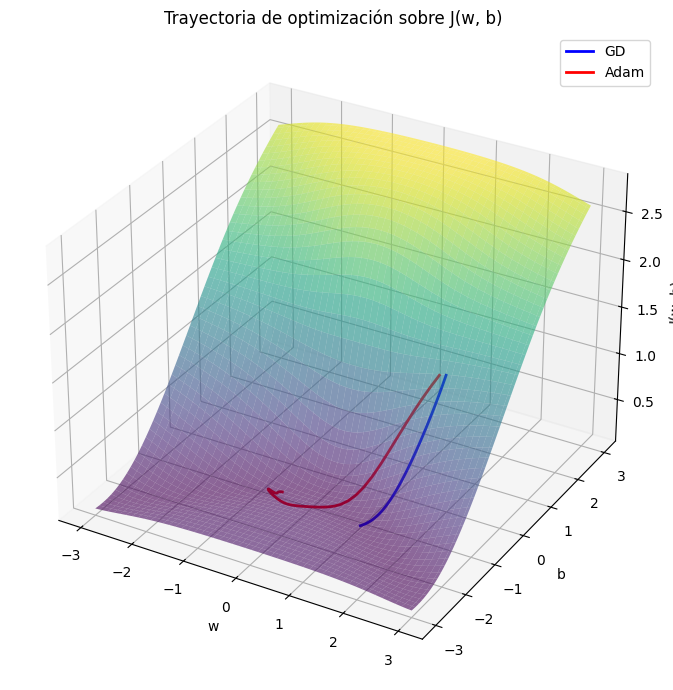

In [64]:
# Función de costo J(w, b)
def compute_loss(X, y, w, b):
    y_hat = tanh(X * w + b)
    return np.mean((y - y_hat)**2)

# Construimos la malla para la superficie
w_vals = np.linspace(-3, 3, 100)
b_vals = np.linspace(-3, 3, 100)
W, B = np.meshgrid(w_vals, b_vals)

# Evaluamos J(w, b) para cada punto
J_vals = np.zeros_like(W)
for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J_vals[i, j] = compute_loss(X, y, W[i, j], B[i, j])


# Extraer coordenadas
w_gd, b_gd, j_gd = zip(*trace_gd)
w_adam, b_adam, j_adam = zip(*trace_adam)


fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Superficie de pérdida
ax.plot_surface(W, B, J_vals, cmap='viridis', alpha=0.6, edgecolor='none')

# Trayectorias
ax.plot(w_gd, b_gd, j_gd, color='blue', label='GD', linewidth=2)
ax.plot(w_adam, b_adam, j_adam, color='red', label='Adam', linewidth=2)

# Etiquetas
ax.set_title("Trayectoria de optimización sobre J(w, b)")
ax.set_xlabel("w")
ax.set_ylabel("b")
ax.set_zlabel("J(w, b)")
ax.legend()

plt.tight_layout()
plt.show()


En la figura se observa la superficie de la función de costo $𝐽(𝑤,𝑏)$ junto con las trayectorias de los optimizadores GD (azul) y Adam (rojo).

Ambos optimizadores parten del mismo punto inicial. Sin embargo, Adam presenta una convergencia más rápida y directa hacia la zona de mínimo, debido a sus mecanismos adaptativos de momento y escalado de gradientes.

En contraste, GD avanza con pasos más pequeños y requiere más iteraciones para alcanzar una región cercana al mínimo.

Esta visualización permite apreciar claramente cómo las decisiones de actualización de parámetros influyen en la velocidad y eficiencia de la optimización.